In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
##1. Load Dataset:

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [4]:
df.head()
# AT => Temparature
# V => vaccum
# AP => pressure
# RH => Humidity
# PE => Produce energy

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis =1) # Features
y = df["PE"] # Labels

In [7]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [8]:
## Train - Test- Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
df.shape

(9568, 5)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [12]:
## 2. Convert Dataset into Tensors

In [13]:
X_train_tensor = torch.tensor(X_train_scaled , dtype= torch.float32)
y_train_tensor = torch.tensor(y_train.values , dtype= torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype= torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype= torch.float32).view(-1, 1)

In [14]:
## 3. Implement Tensor DataSet and DataLoader

In [15]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [16]:
### Create DataLoader from Dataset

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [17]:
## Deep Learning Part : 

In [18]:
## 4. Define ANN Model

In [19]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layeer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            #2nd Hidden
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6,1),
        )
    # Forward propagation
    def forward(self, x):
        return self.model(x)
    

In [20]:
model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [21]:
##5 . Training ANN Model

In [22]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss of one epoch

    for xb, yb in train_loader: # This trainloader gives us every bacth
        # xb = features of 1 batch
        # yb = labels of 1 batch

        optimizer.zero_grad() #Clears all previous gradients before each training step.
        outputs = model(xb) # (forward propagation)... predicted outputs for this batch
        loss = criterion(outputs, yb) # it returns MSELoss
        loss.backward() # back prop... compute gradients
        optimizer.step() # params update using step function

        running_loss += loss.item() # loss is tensor value => py float
        
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # No gradients compute
        for xb , yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")
    

epoch 1/100 ==> train loss = 205711.05052083332 & val loss = 202637.359375
epoch 2/100 ==> train loss = 192321.590625 & val loss = 176022.484375
epoch 3/100 ==> train loss = 147200.1517903646 & val loss = 114294.9921875
epoch 4/100 ==> train loss = 83037.22514648437 & val loss = 56271.94140625
epoch 5/100 ==> train loss = 40740.47760416667 & val loss = 28762.064453125
epoch 6/100 ==> train loss = 23137.764408365885 & val loss = 17956.78125
epoch 7/100 ==> train loss = 15758.307975260417 & val loss = 13009.626953125
epoch 8/100 ==> train loss = 11636.194217936198 & val loss = 9595.3974609375
epoch 9/100 ==> train loss = 8391.892454020182 & val loss = 6698.59326171875
epoch 10/100 ==> train loss = 5715.874954223633 & val loss = 4456.8662109375
epoch 11/100 ==> train loss = 3817.6062388102214 & val loss = 3006.340087890625
epoch 12/100 ==> train loss = 2623.1783915201822 & val loss = 2106.769775390625
epoch 13/100 ==> train loss = 1878.3868153889973 & val loss = 1529.1881103515625
epoch 1

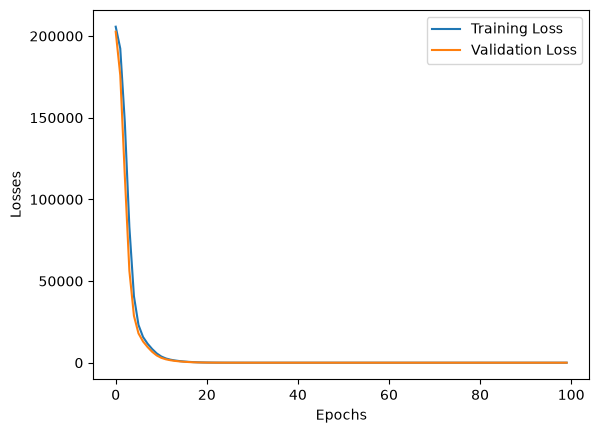

In [23]:
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()